In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np # Import numpy for polyfit
from scipy.stats import pearsonr # Import pearsonr
import scipy.stats as stats
import seaborn as sns

# Define file paths relative to the notebook's directory or use absolute paths
log_dir = '../logs0/DNAWhisperfinetune/run0_blockembedding_pke_30k'    
# logs0/DNAWhisperfinetune/run0_blockembedding_grape_30k/train_pooling_weights.h5' ./logs0/DNAWhisperfinetune/run0_blockembedding_grape_30k/
# ../logs0/DNAWhisperfinetune/run0_blockembedding_f3p_30k' 
# ../logs0/DNAWhisperfinetune/run0_blockembedding_ph_30k
# ../logs0/DNAWhisperfinetune/run0_blockembedding_pke_30k
# Adjust if the notebook is not in the 'notebooks' directory
train_file = os.path.join(log_dir, 'train_predictions.csv')
val_file = os.path.join(log_dir, 'val_predictions.csv')
test_file = os.path.join(log_dir, 'test_predictions.csv')

# Load the datasets
try:
    train_df = pd.read_csv(train_file)
    val_df = pd.read_csv(val_file)
    test_df = pd.read_csv(test_file)
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please check the file paths.")
    # Add placeholder dataframes or exit if files are essential
    train_df, val_df, test_df = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    # train_df = pd.DataFrame()

# Identify phenotypes (assuming pattern like 'XXX_pred', 'XXX_label')
# Filter out columns that don't fit the pattern to avoid errors
phenotypes = sorted(list(set([col.split('_')[0] for col in train_df.columns if '_' in col])))

# Define colors for different datasets
# colors = {'train': 'blue', 'val': 'orange', 'test': 'green'}  #'train': 'blue', 'train': 'blue', 
# datasets = {'train': train_df, 'val': val_df, 'test': test_df}  #'train': train_df, 'train': train_df, 

colors = {'val': 'orange', 'test': 'green'}  #'train': 'blue', 'train': 'blue', 
datasets = {'val': val_df, 'test': test_df}  #'train': train_df, 'train': train_df, 

#colors = {'train': 'blue', 'val': 'orange', 'test': 'green'}  #'train': 'blue', 'train': 'blue', 
#datasets = {'train': train_df}  #'train': train_df, 'train': train_df, 

Analyzing residuals for normality in train_df:

--- Phenotype: hard ---


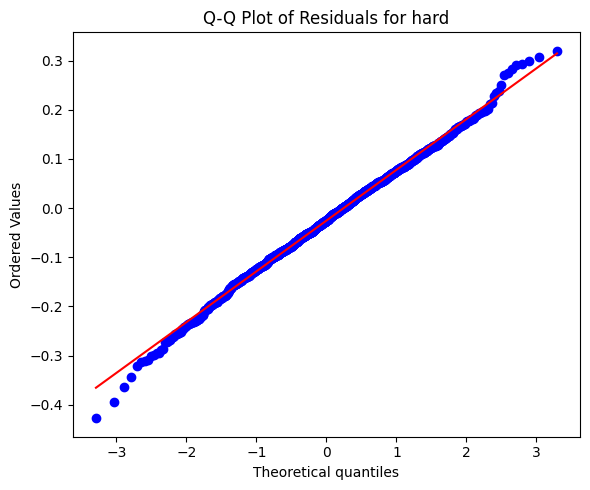

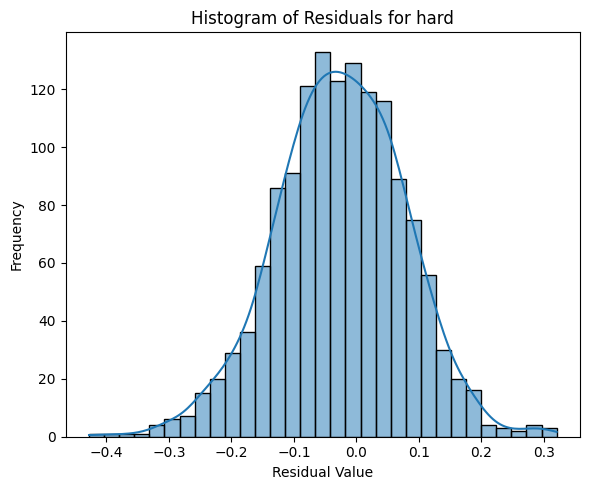

  Shapiro-Wilk Test for hard:
    Statistic: 0.9977, p-value: 0.0433
    Conclusion: Sample does not look Gaussian (reject H0)

--- Phenotype: length ---


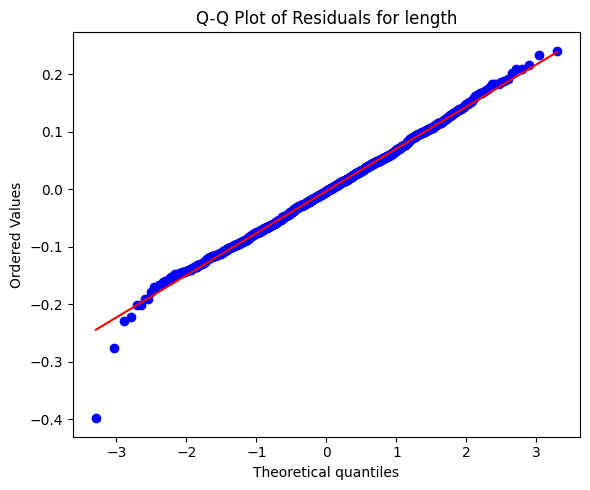

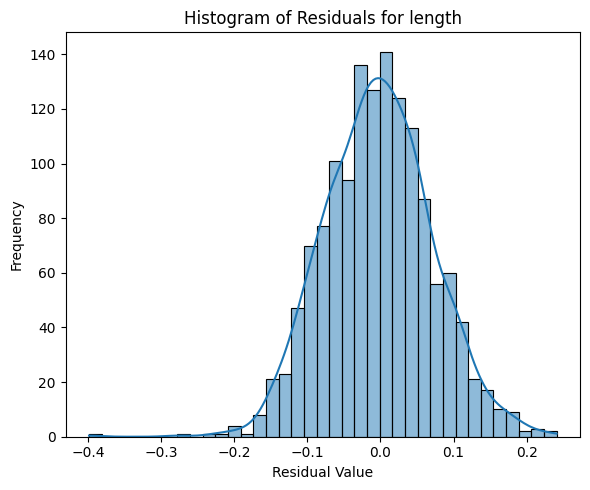

  Shapiro-Wilk Test for length:
    Statistic: 0.9960, p-value: 0.0009
    Conclusion: Sample does not look Gaussian (reject H0)

--- Phenotype: prot ---


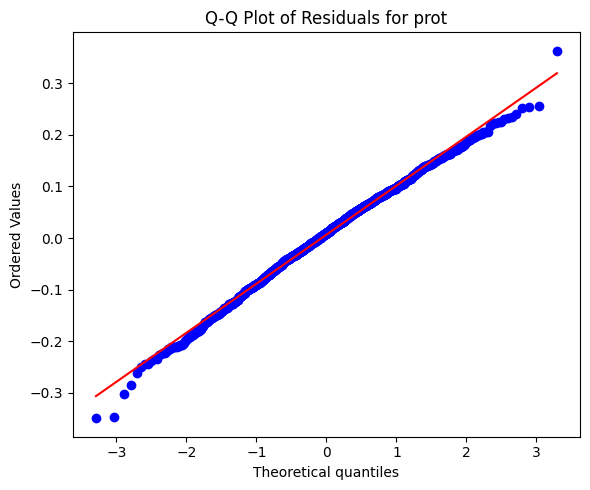

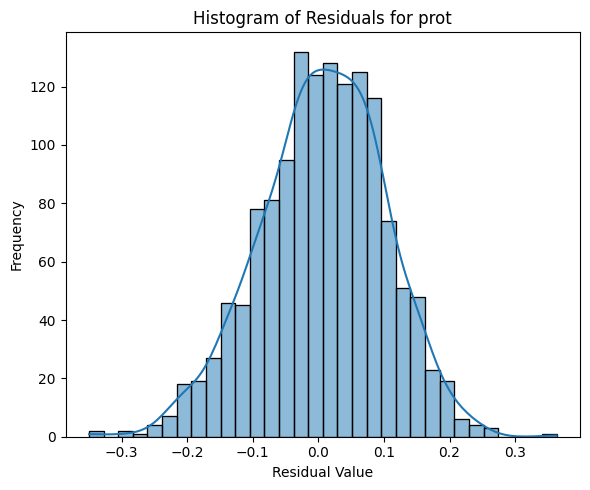

  Shapiro-Wilk Test for prot:
    Statistic: 0.9966, p-value: 0.0038
    Conclusion: Sample does not look Gaussian (reject H0)

--- Phenotype: testw ---


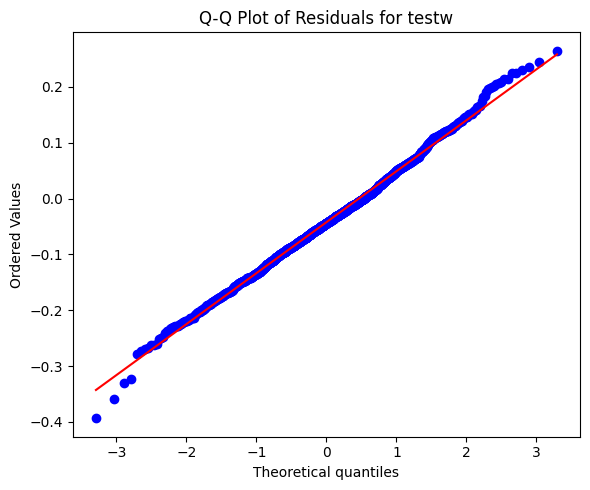

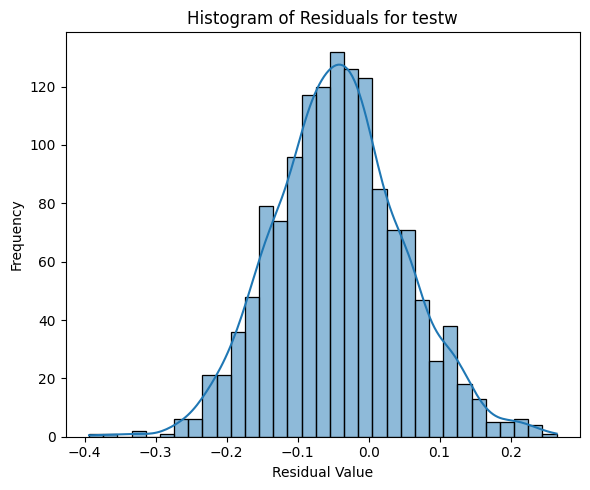

  Shapiro-Wilk Test for testw:
    Statistic: 0.9973, p-value: 0.0182
    Conclusion: Sample does not look Gaussian (reject H0)

--- Phenotype: tkw ---


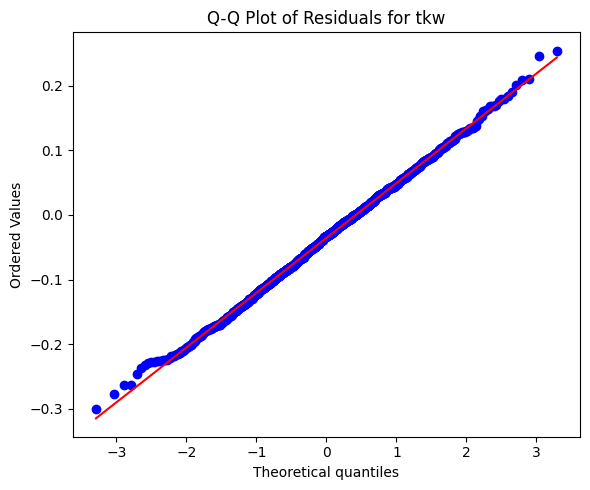

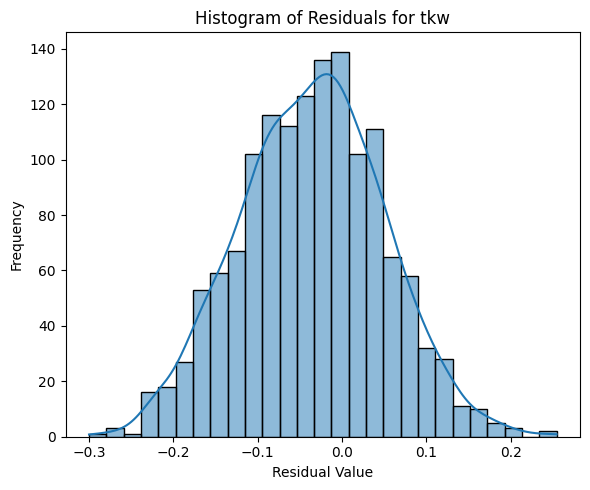

  Shapiro-Wilk Test for tkw:
    Statistic: 0.9989, p-value: 0.6025
    Conclusion: Sample looks Gaussian (fail to reject H0)

--- Phenotype: width ---


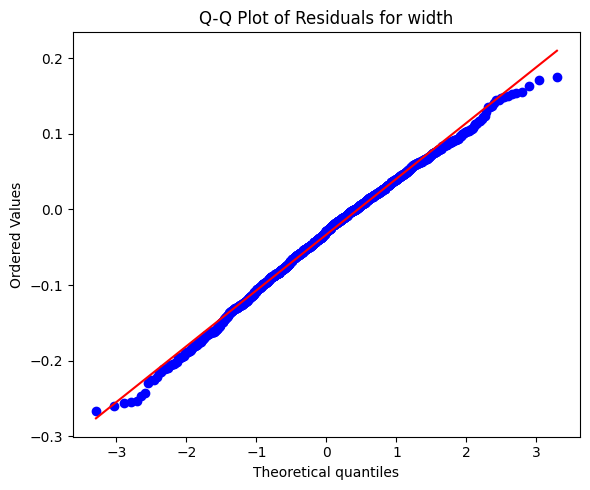

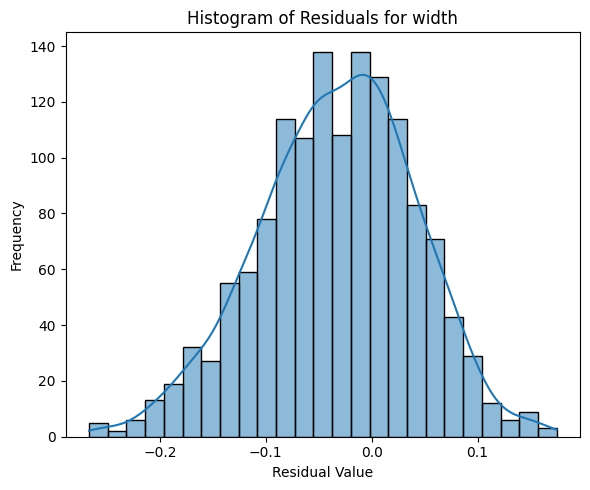

  Shapiro-Wilk Test for width:
    Statistic: 0.9963, p-value: 0.0017
    Conclusion: Sample does not look Gaussian (reject H0)


In [4]:
# Plotting function
# Ensure train_df is loaded and not empty
if 'train_df' in globals() and not train_df.empty:
    # Phenotypes should already be defined from the previous cell
    # If not, uncomment and adapt the line below:
    # phenotypes = sorted(list(set([col.split('_')[0] for col in train_df.columns if '_' in col and any(c.isdigit() for c in col.split('_')[0]) ])))))

    print("Analyzing residuals for normality in train_df:")
    for pheno in phenotypes:
        pred_col = f"{pheno}_pred"
        label_col = f"{pheno}_label"

        if pred_col in train_df.columns and label_col in train_df.columns:
            # Calculate residuals
            residuals = train_df[pred_col] - train_df[label_col]

            if residuals.empty or residuals.nunique() < 2: # Check if residuals are empty or all same value
                print(f"\n--- Phenotype: {pheno} ---")
                print("  Skipping normality check: Not enough distinct residual values.")
                continue

            print(f"\n--- Phenotype: {pheno} ---")

            # 1. Q-Q Plot (separate figure)
            plt.figure(figsize=(6, 5))
            stats.probplot(residuals, dist="norm", plot=plt)
            plt.title(f'Q-Q Plot of Residuals for {pheno}')
            plt.tight_layout()
            plt.show()

            # 2. Histogram of Residuals (separate figure)
            plt.figure(figsize=(6, 5))
            sns.histplot(residuals, kde=True)
            plt.title(f'Histogram of Residuals for {pheno}')
            plt.xlabel('Residual Value')
            plt.ylabel('Frequency')
            plt.tight_layout()
            plt.show()

            # 3. Shapiro-Wilk Test for normality
            # The Shapiro-Wilk test tests the null hypothesis that the
            # data was drawn from a normal distribution.
            # Requires at least 3 data points.
            if len(residuals) >= 3:
                shapiro_stat, shapiro_p_value = stats.shapiro(residuals)
                print(f"  Shapiro-Wilk Test for {pheno}:")
                print(f"    Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p_value:.4f}")
                if shapiro_p_value > 0.05:
                    print("    Conclusion: Sample looks Gaussian (fail to reject H0)")
                else:
                    print("    Conclusion: Sample does not look Gaussian (reject H0)")
            else:
                print(f"  Shapiro-Wilk Test for {pheno}: Not enough data points (need at least 3).")

        else:
            print(f"\nSkipping phenotype {pheno}: Columns {pred_col} or {label_col} not found in train_df.")
else:
    print("train_df is not loaded or is empty. Please load the data first.")

In [ ]:
# Plotting
for pheno in phenotypes:
    pred_col = f"{pheno}_pred"
    label_col = f"{pheno}_label"

    # Check if columns exist in all dataframes before plotting
    if all(pred_col in df.columns and label_col in df.columns for df in datasets.values() if not df.empty):
        plt.figure(figsize=(8, 8))
        all_labels = []
        all_preds = []

        for name, df in datasets.items():
            if not df.empty and pred_col in df.columns and label_col in df.columns:
                labels = df[label_col]
                preds = df[pred_col]
                all_labels.extend(labels)
                all_preds.extend(preds)

                # Calculate Pearson correlation
                # Handle cases with zero standard deviation (constant values) which lead to NaN correlation
                if labels.std() > 0 and preds.std() > 0:
                    corr, _ = pearsonr(labels, preds)
                    label_text = f'{name} (r={corr:.2f})' # Add correlation to legend
                else:
                    corr = np.nan # Assign NaN if correlation cannot be computed
                    label_text = f'{name} (r=N/A)' # Indicate N/A in legend

                plt.scatter(labels, preds, label=label_text, color=colors[name], alpha=0.5, s=10) # Smaller points

        # Calculate overall min/max for plot limits and fit line
        if all_labels and all_preds: # Ensure lists are not empty
            min_val = min(min(all_labels), min(all_preds))
            max_val = max(max(all_labels), max(all_preds))
            plot_min = min_val - abs(min_val)*0.05
            plot_max = max_val + abs(max_val)*0.05


            # Add a diagonal line for reference (y=x)
            plt.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', alpha=0.7, label='y=x') # Changed to black dashed

            # Calculate and plot the linear fit line for all data combined
            # Ensure there's variance in the combined data before fitting
            if np.std(all_labels) > 0 and np.std(all_preds) > 0:
                 coeffs = np.polyfit(all_labels, all_preds, 1) # Linear fit (degree 1)
                 poly = np.poly1d(coeffs)
                 x_fit = np.linspace(min_val, max_val, 100) # Use actual min/max for fit line range
                 y_fit = poly(x_fit)
                 plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit (y={coeffs[0]:.2f}x+{coeffs[1]:.2f})') # Red solid line, thicker
            else:
                 print(f"Skipping fit line for {pheno}: Insufficient variance in combined data.")


            plt.title(f'{pheno}: Prediction vs Label')
            plt.xlabel(f'{pheno} Label')
            plt.ylabel(f'{pheno} Prediction')
            plt.legend()
            plt.grid(True)
            # Adjust axis limits slightly beyond min/max for better visualization
            plt.xlim(plot_min, plot_max)
            plt.ylim(plot_min, plot_max)
            # plt.axis('equal') # Keep or remove based on preference, might distort view if ranges differ significantly
            plt.show()
        else:
             print(f"Skipping plot for {pheno}: No data found after filtering.")

    else:
        # Check which specific columns are missing if the 'all' condition fails
        missing_info = []
        for name, df in datasets.items():
            if df.empty: continue
            if pred_col not in df.columns: missing_info.append(f"{name}:{pred_col}")
            if label_col not in df.columns: missing_info.append(f"{name}:{label_col}")
        print(f"Skipping plot for {pheno}: Columns missing - {', '.join(missing_info)}")

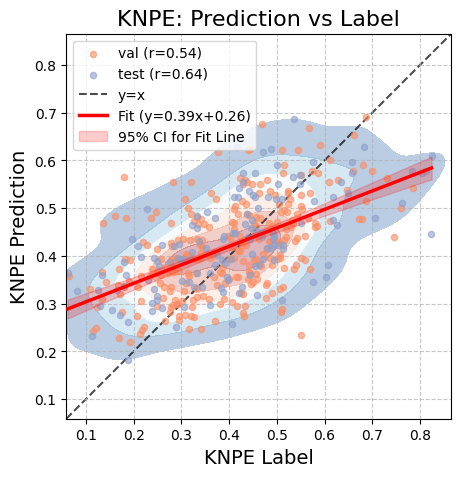

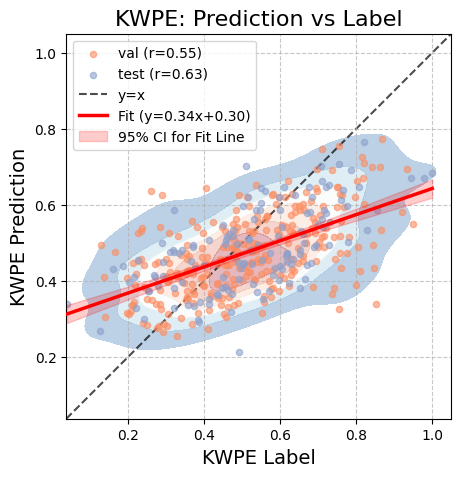

In [16]:
# Plotting
# Define more harmonious colors for scatter plots
scatter_plot_colors = {
    'train': sns.color_palette("Set2")[0], # Example: Seaborn's Set2 palette
    'val': sns.color_palette("Set2")[1],
    'test': sns.color_palette("Set2")[2]
}
# If you prefer to update the global 'colors' dictionary from the first cell:
# colors = scatter_plot_colors # Uncomment this line if you want to modify the global 'colors'

for pheno in phenotypes:
    pred_col = f"{pheno}_pred"
    label_col = f"{pheno}_label"

    # Check if columns exist in all dataframes before plotting
    if all(pred_col in df.columns and label_col in df.columns for df in datasets.values() if not df.empty):
        plt.figure(figsize=(5, 5)) # Slightly larger figure for better visibility
        all_labels = []
        all_preds = []

        # First, collect all data and plot scatter points for individual datasets
        for name, df in datasets.items():
            if not df.empty and pred_col in df.columns and label_col in df.columns:
                labels = df[label_col]
                preds = df[pred_col]
                all_labels.extend(labels.tolist()) # Ensure they are lists for extend
                all_preds.extend(preds.tolist())

                # Calculate Pearson correlation
                if labels.std() > 0 and preds.std() > 0:
                    corr, _ = pearsonr(labels, preds)
                    label_text = f'{name} (r={corr:.2f})'
                else:
                    corr = np.nan
                    label_text = f'{name} (r=N/A)'
                
                # Use the new color scheme for scatter plots
                current_color = scatter_plot_colors.get(name, 'gray') # Fallback to gray if name not in dict
                plt.scatter(labels, preds, label=label_text, color=current_color, alpha=0.6, s=20, zorder=2) # zorder=2 for scatter

        # Calculate overall min/max for plot limits and fit line
        if all_labels and all_preds: # Ensure lists are not empty
            # Convert to numpy arrays for calculations
            np_all_labels = np.array(all_labels)
            np_all_preds = np.array(all_preds)

            min_val = min(np_all_labels.min(), np_all_preds.min())
            max_val = max(np_all_labels.max(), np_all_preds.max())
            
            # Add buffer, handle potential zero values for buffer calculation
            buffer_min_abs = abs(min_val) * 0.05 if min_val != 0 else 0.1
            buffer_max_abs = abs(max_val) * 0.05 if max_val != 0 else 0.1
            plot_min = min_val - buffer_min_abs
            plot_max = max_val + buffer_max_abs

            # Add 2D KDE plot (contour lines) for all data combined
            if len(np_all_labels) > 1 and len(np_all_preds) > 1: # KDE needs some data
                try:
                    sns.kdeplot(x=np_all_labels, y=np_all_preds, fill=True, cmap="RdBu_r",  #Blues coolwarm RdBu PiYG
                                alpha=0.3, levels=7, thresh=0.05, zorder=0) # zorder=0 for background
                except Exception as e:
                    print(f"Could not plot KDE for {pheno}: {e}")


            # Add a diagonal line for reference (y=x)
            plt.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', alpha=0.7, label='y=x', zorder=1)

            # Calculate and plot the linear fit line and confidence interval for all data combined
            if np_all_labels.std() > 0 and np_all_preds.std() > 0 and len(np_all_labels) > 2: # Need >2 points for CI
                 # Fit linear regression
                 coeffs, cov_matrix = np.polyfit(np_all_labels, np_all_preds, 1, cov=True) # deg=1 for linear, get covariance matrix
                 poly = np.poly1d(coeffs)
                 
                 # Generate points for fit line
                 x_fit = np.linspace(min_val, max_val, 200) # Use actual min/max for fit line range
                 y_fit = poly(x_fit)
                 
                 # Calculate 95% confidence interval for the fit line
                 # t-value for 95% CI with n-2 degrees of freedom (for linear fit)
                 n = len(np_all_labels)
                 dof = n - 2 
                 t_crit = stats.t.ppf(1 - 0.05 / 2, dof)
                 
                 # Variance of the predicted mean response: X_p @ cov_matrix @ X_p.T
                 # X_p = [x, 1]
                 ci_band_half_width = np.zeros_like(x_fit)
                 for i, x_val in enumerate(x_fit):
                     design_vec = np.array([x_val, 1.0])
                     var_pred_mean = design_vec @ cov_matrix @ design_vec.T
                     se_pred_mean = np.sqrt(var_pred_mean)
                     ci_band_half_width[i] = t_crit * se_pred_mean

                 plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Fit (y={coeffs[0]:.2f}x+{coeffs[1]:.2f})', zorder=3)
                 plt.fill_between(x_fit, y_fit - ci_band_half_width, y_fit + ci_band_half_width, 
                                  color='red', alpha=0.2, label='95% CI for Fit Line', zorder=2.5)
            elif np_all_labels.std() > 0 and np_all_preds.std() > 0: # Can still plot fit line if not enough for CI
                 coeffs = np.polyfit(np_all_labels, np_all_preds, 1)
                 poly = np.poly1d(coeffs)
                 x_fit = np.linspace(min_val, max_val, 200)
                 y_fit = poly(x_fit)
                 plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Fit (y={coeffs[0]:.2f}x+{coeffs[1]:.2f})', zorder=3)
                 print(f"Skipping confidence interval for {pheno}: Insufficient data points (need >2).")
            else:
                 print(f"Skipping fit line and CI for {pheno}: Insufficient variance or data points in combined data.")

            # plt.title(f'Grape187 {pheno}: Prediction vs Label', fontsize=16)
            plt.title(f'{pheno}: Prediction vs Label', fontsize=16)
            plt.xlabel(f'{pheno} Label', fontsize=14)
            plt.ylabel(f'{pheno} Prediction', fontsize=14)
            plt.legend(fontsize=10)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.xlim(plot_min, plot_max)
            plt.ylim(plot_min, plot_max)
            plt.gca().set_aspect('equal', adjustable='box') # Make axes equal
            plt.show()
        else:
             print(f"Skipping plot for {pheno}: No data found after filtering.")

    else:
        missing_info = []
        for name, df in datasets.items():
            if df.empty: continue
            if pred_col not in df.columns: missing_info.append(f"{name}:{pred_col}")
            if label_col not in df.columns: missing_info.append(f"{name}:{label_col}")
        if missing_info:
            print(f"Skipping plot for {pheno}: Columns missing - {', '.join(missing_info)}")
        # else: Initial check failed, possibly due to an empty dataframe where others had columns.

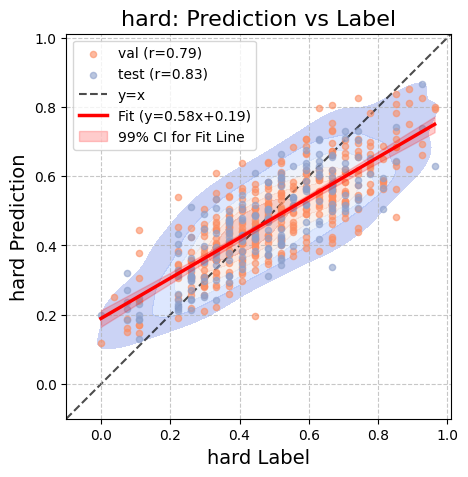

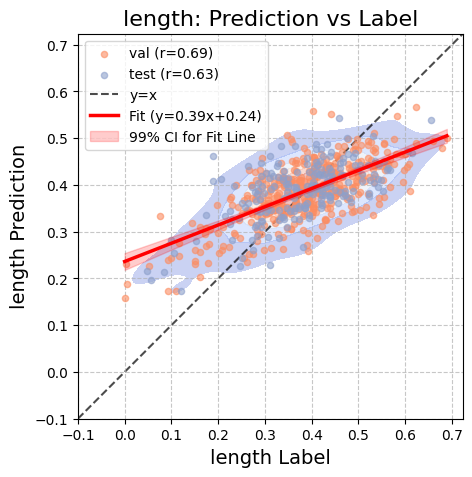

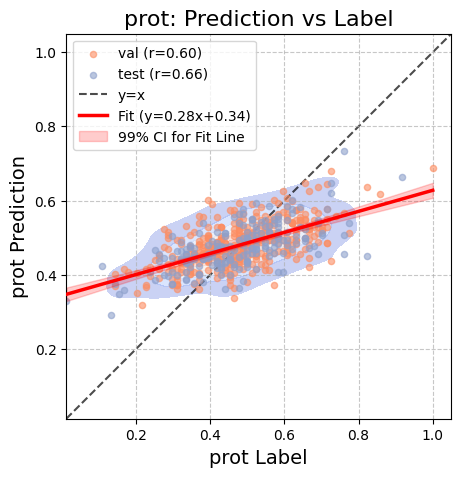

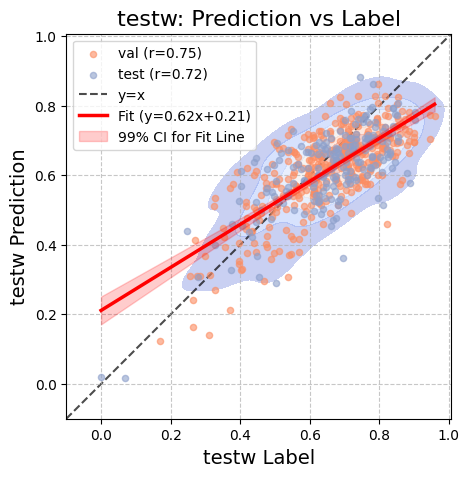

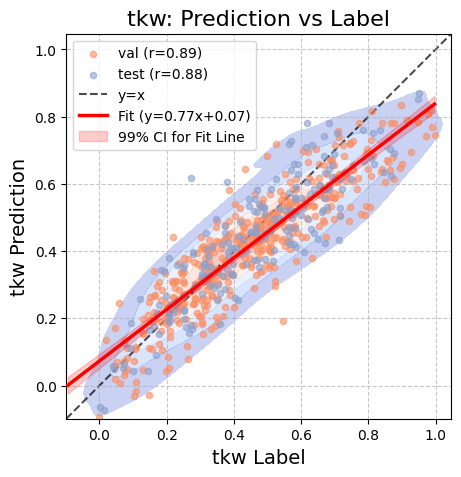

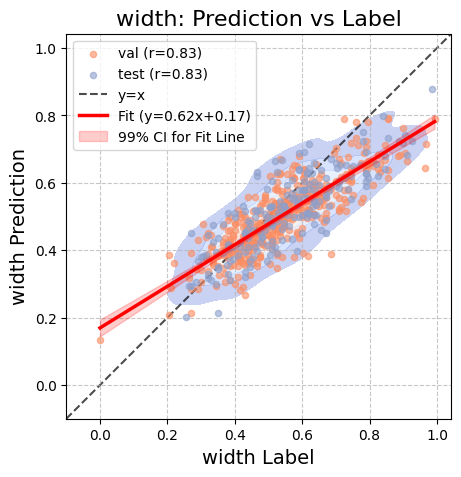

In [7]:
# Plotting
# Define more harmonious colors for scatter plots
scatter_plot_colors = {
    'train': sns.color_palette("Set2")[0], # Example: Seaborn's Set2 palette
    'val': sns.color_palette("Set2")[1],
    'test': sns.color_palette("Set2")[2]
}
# If you prefer to update the global 'colors' dictionary from the first cell:
# colors = scatter_plot_colors # Uncomment this line if you want to modify the global 'colors'

for pheno in phenotypes:
    pred_col = f"{pheno}_pred"
    label_col = f"{pheno}_label"

    # Check if columns exist in all dataframes before plotting
    if all(pred_col in df.columns and label_col in df.columns for df in datasets.values() if not df.empty):
        plt.figure(figsize=(5, 5)) # Slightly larger figure for better visibility
        all_labels = []
        all_preds = []

        # First, collect all data and plot scatter points for individual datasets
        for name, df in datasets.items():
            if not df.empty and pred_col in df.columns and label_col in df.columns:
                labels = df[label_col]
                preds = df[pred_col]
                all_labels.extend(labels.tolist()) # Ensure they are lists for extend
                all_preds.extend(preds.tolist())

                # Calculate Pearson correlation
                if labels.std() > 0 and preds.std() > 0:
                    corr, _ = pearsonr(labels, preds)
                    label_text = f'{name} (r={corr:.2f})'
                else:
                    corr = np.nan
                    label_text = f'{name} (r=N/A)'
                
                # Use the new color scheme for scatter plots
                current_color = scatter_plot_colors.get(name, 'gray') # Fallback to gray if name not in dict
                plt.scatter(labels, preds, label=label_text, color=current_color, alpha=0.6, s=20, zorder=2) # zorder=2 for scatter

        # Calculate overall min/max for plot limits and fit line
        if all_labels and all_preds: # Ensure lists are not empty
            # Convert to numpy arrays for calculations
            np_all_labels = np.array(all_labels)
            np_all_preds = np.array(all_preds)

            min_val = min(np_all_labels.min(), np_all_preds.min())
            max_val = max(np_all_labels.max(), np_all_preds.max())
            
            # Add buffer, handle potential zero values for buffer calculation
            buffer_min_abs = abs(min_val) * 0.05 if min_val != 0 else 0.1
            buffer_max_abs = abs(max_val) * 0.05 if max_val != 0 else 0.1
            plot_min = min_val - buffer_min_abs
            plot_max = max_val + buffer_max_abs

            # Add 2D KDE plot (contour lines) for all data combined
            if len(np_all_labels) > 1 and len(np_all_preds) > 1: # KDE needs some data
                try:
                    sns.kdeplot(x=np_all_labels, y=np_all_preds, fill=True, cmap="coolwarm", 
                                alpha=0.3, levels=7, thresh=0.05, zorder=0) # zorder=0 for background
                except Exception as e:
                    print(f"Could not plot KDE for {pheno}: {e}")


            # Add a diagonal line for reference (y=x)
            plt.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', alpha=0.7, label='y=x', zorder=1)

            # Calculate and plot the linear fit line and confidence interval for all data combined
            if np_all_labels.std() > 0 and np_all_preds.std() > 0 and len(np_all_labels) > 2: # Need >2 points for CI
                 # Fit linear regression
                 coeffs, cov_matrix = np.polyfit(np_all_labels, np_all_preds, 1, cov=True) # deg=1 for linear, get covariance matrix
                 poly = np.poly1d(coeffs)
                 
                 # Generate points for fit line
                 x_fit = np.linspace(min_val, max_val, 200) # Use actual min/max for fit line range
                 y_fit = poly(x_fit)
                 
                 # Calculate 99% confidence interval for the fit line
                 n = len(np_all_labels)
                 dof = n - 2 
                 t_crit = stats.t.ppf(1 - 0.01 / 2, dof) # Changed from 0.05 to 0.01 for 99% CI
                 
                 ci_band_half_width = np.zeros_like(x_fit)
                 for i, x_val in enumerate(x_fit):
                     design_vec = np.array([x_val, 1.0])
                     var_pred_mean = design_vec @ cov_matrix @ design_vec.T
                     se_pred_mean = np.sqrt(var_pred_mean)
                     ci_band_half_width[i] = t_crit * se_pred_mean

                 plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Fit (y={coeffs[0]:.2f}x+{coeffs[1]:.2f})', zorder=3)
                 plt.fill_between(x_fit, y_fit - ci_band_half_width, y_fit + ci_band_half_width, 
                                  color='red', alpha=0.2, label='99% CI for Fit Line', zorder=2.5) # Updated label to 99% CI
            elif np_all_labels.std() > 0 and np_all_preds.std() > 0: # Can still plot fit line if not enough for CI
                 coeffs = np.polyfit(np_all_labels, np_all_preds, 1)
                 poly = np.poly1d(coeffs)
                 x_fit = np.linspace(min_val, max_val, 200)
                 y_fit = poly(x_fit)
                 plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Fit (y={coeffs[0]:.2f}x+{coeffs[1]:.2f})', zorder=3)
                 print(f"Skipping confidence interval for {pheno}: Insufficient data points (need >2).")
            else:
                 print(f"Skipping fit line and CI for {pheno}: Insufficient variance or data points in combined data.")

            plt.title(f'{pheno}: Prediction vs Label', fontsize=16)
            plt.xlabel(f'{pheno} Label', fontsize=14)
            plt.ylabel(f'{pheno} Prediction', fontsize=14)
            plt.legend(fontsize=10)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.xlim(plot_min, plot_max)
            plt.ylim(plot_min, plot_max)
            plt.gca().set_aspect('equal', adjustable='box') # Make axes equal
            plt.show()
        else:
             print(f"Skipping plot for {pheno}: No data found after filtering.")

    else:
        missing_info = []
        for name, df in datasets.items():
            if df.empty: continue
            if pred_col not in df.columns: missing_info.append(f"{name}:{pred_col}")
            if label_col not in df.columns: missing_info.append(f"{name}:{label_col}")
        if missing_info:
            print(f"Skipping plot for {pheno}: Columns missing - {', '.join(missing_info)}")
        # else: Initial check failed, possibly due to an empty dataframe where others had columns.

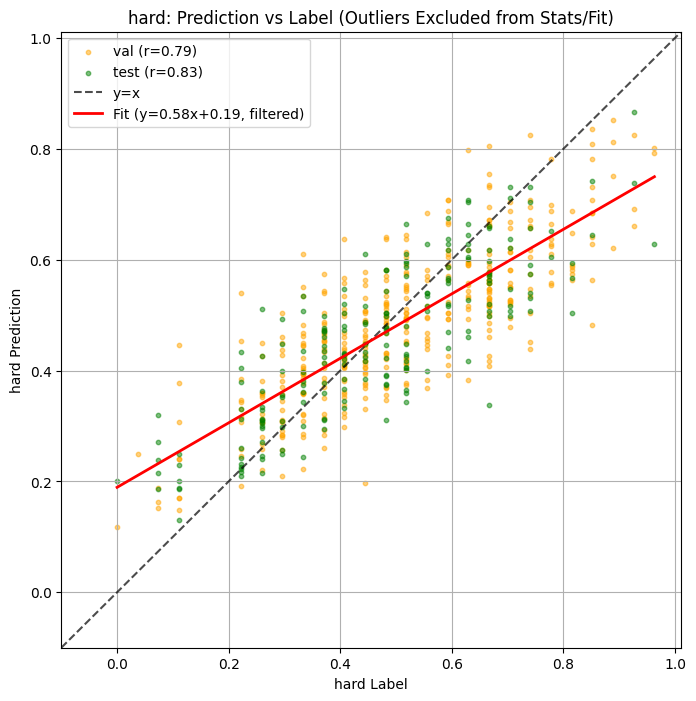

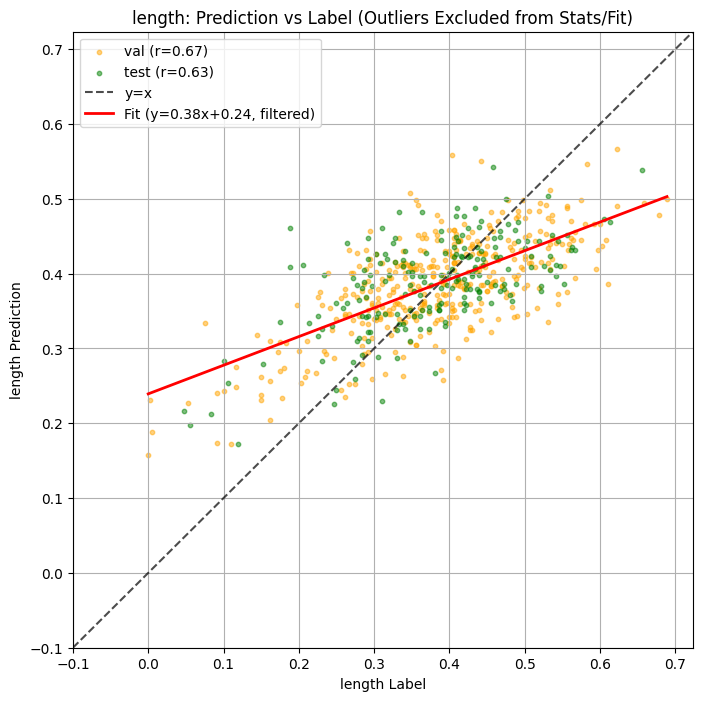

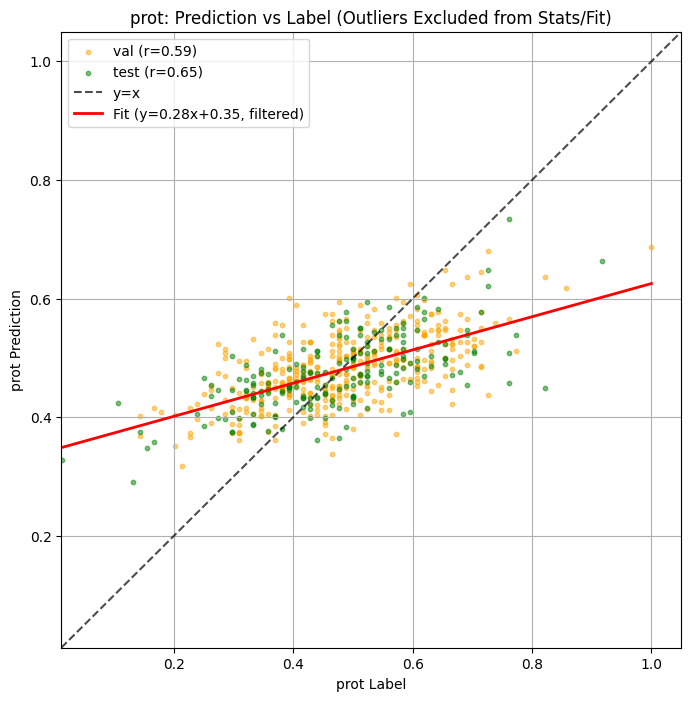

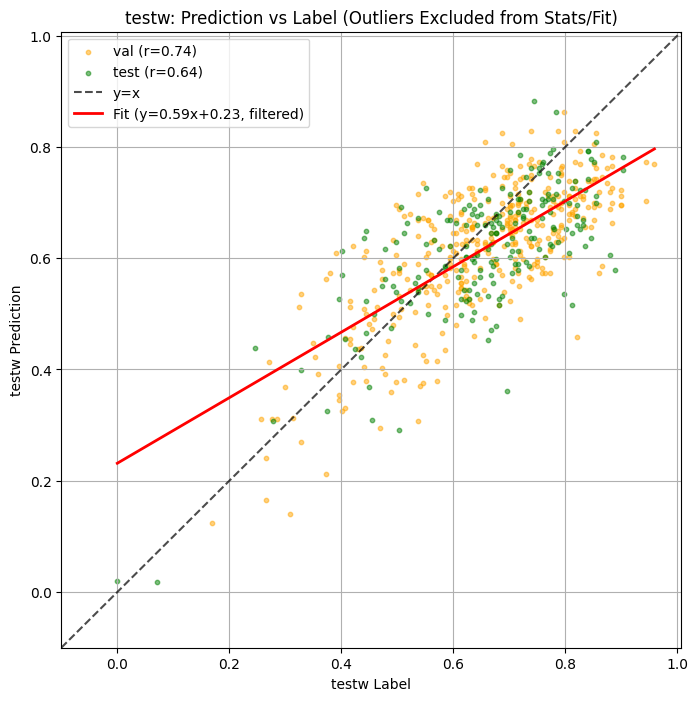

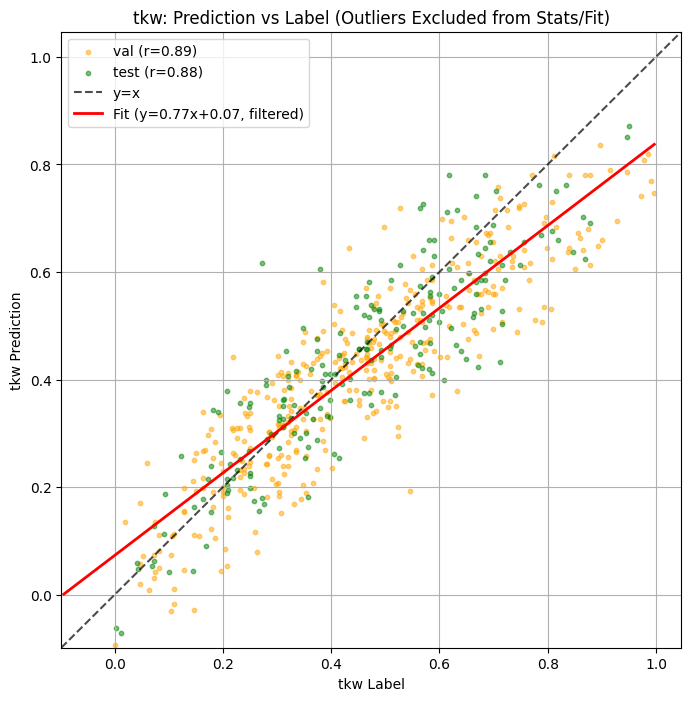

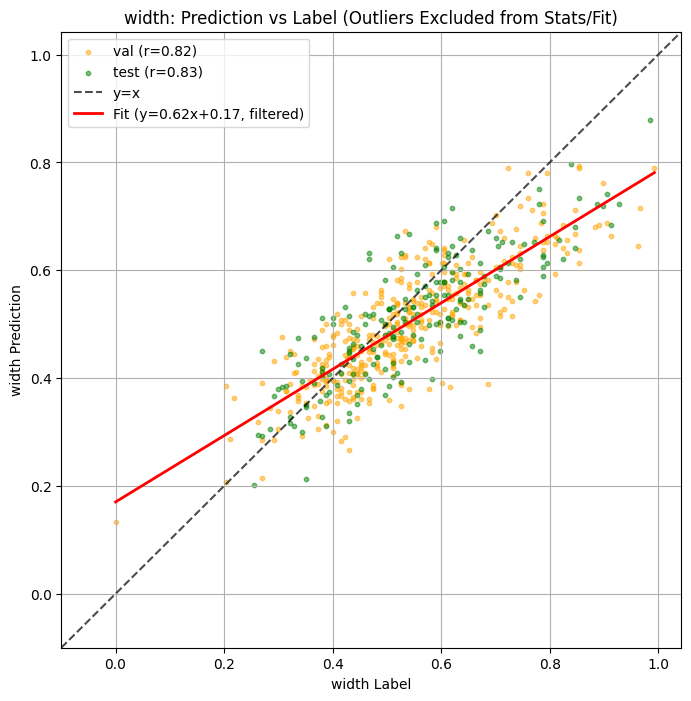

In [8]:
# ... existing code ...
# Plotting
for pheno in phenotypes:
    pred_col = f"{pheno}_pred"
    label_col = f"{pheno}_label"

    # Check if columns exist in all dataframes before plotting
    if all(pred_col in df.columns and label_col in df.columns for df in datasets.values() if not df.empty):
        plt.figure(figsize=(8, 8))
        all_labels_original = [] # Store original labels for plot limits
        all_preds_original = []  # Store original predictions for plot limits
        all_labels_filtered_for_fit = [] # Store filtered labels for combined fit
        all_preds_filtered_for_fit = []  # Store filtered predictions for combined fit

        for name, df in datasets.items():
            if not df.empty and pred_col in df.columns and label_col in df.columns:
                labels_original = df[label_col]
                preds_original = df[pred_col]
                all_labels_original.extend(labels_original)
                all_preds_original.extend(preds_original)

                # --- Outlier removal based on labels for correlation calculation ---
                Q1 = labels_original.quantile(0.25)
                Q3 = labels_original.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 2 * IQR
                upper_bound = Q3 + 2 * IQR

                # Filter data based on label outliers
                mask = (labels_original >= lower_bound) & (labels_original <= upper_bound)
                labels_filtered = labels_original[mask]
                preds_filtered = preds_original[mask]
                # --------------------------------------------------------------------

                # Append filtered data for the combined fit line calculation later
                all_labels_filtered_for_fit.extend(labels_filtered)
                all_preds_filtered_for_fit.extend(preds_filtered)

                # Calculate Pearson correlation on filtered data
                corr = np.nan # Default to NaN
                label_text = f'{name} (r=N/A)' # Default legend text
                if not labels_filtered.empty and not preds_filtered.empty and labels_filtered.std() > 0 and preds_filtered.std() > 0:
                    corr, _ = pearsonr(labels_filtered, preds_filtered)
                    label_text = f'{name} (r={corr:.2f})' # Add correlation to legend
                elif not labels_filtered.empty and not preds_filtered.empty:
                     # Handle case where std is 0 after filtering but data exists
                     if labels_filtered.nunique() == 1 and preds_filtered.nunique() == 1 and labels_filtered.iloc[0] == preds_filtered.iloc[0]:
                         corr = 1.0 # Perfect correlation if all filtered points are identical and equal
                         label_text = f'{name} (r={corr:.2f})'
                     elif labels_filtered.nunique() == 1 or preds_filtered.nunique() == 1:
                         label_text = f'{name} (r=N/A, no variance)' # Indicate no variance after filtering
                     # else: leave as N/A

                # Plot original data points
                plt.scatter(labels_original, preds_original, label=label_text, color=colors[name], alpha=0.5, s=10) # Smaller points

        # Calculate overall min/max for plot limits using original data
        if all_labels_original and all_preds_original: # Ensure lists are not empty
            min_val = min(min(all_labels_original), min(all_preds_original))
            max_val = max(max(all_labels_original), max(all_preds_original))
            # Add buffer, handle potential zero values
            buffer_min = abs(min_val) * 0.05 if min_val != 0 else 0.1
            buffer_max = abs(max_val) * 0.05 if max_val != 0 else 0.1
            plot_min = min_val - buffer_min
            plot_max = max_val + buffer_max


            # Add a diagonal line for reference (y=x)
            plt.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', alpha=0.7, label='y=x') # Changed to black dashed

            # Calculate and plot the linear fit line using combined *filtered* data
            # Convert lists to numpy arrays for polyfit
            np_labels_fit = np.array(all_labels_filtered_for_fit)
            np_preds_fit = np.array(all_preds_filtered_for_fit)

            # Ensure there's variance in the combined filtered data before fitting
            if np_labels_fit.size > 1 and np_preds_fit.size > 1 and np.std(np_labels_fit) > 0 and np.std(np_preds_fit) > 0:
                 coeffs = np.polyfit(np_labels_fit, np_preds_fit, 1) # Linear fit (degree 1) on filtered data
                 poly = np.poly1d(coeffs)
                 # Use original min/max for the range of the fit line to cover the plot area
                 x_fit = np.linspace(min_val, max_val, 100)
                 y_fit = poly(x_fit)
                 plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit (y={coeffs[0]:.2f}x+{coeffs[1]:.2f}, filtered)') # Red solid line, thicker
            elif np_labels_fit.size > 0 or np_preds_fit.size > 0: # Check if any filtered data exists
                 print(f"Skipping fit line for {pheno}: Insufficient variance in combined filtered data.")
            # else: No filtered data at all, do nothing for fit line


            plt.title(f'{pheno}: Prediction vs Label (Outliers Excluded from Stats/Fit)')
            plt.xlabel(f'{pheno} Label')
            plt.ylabel(f'{pheno} Prediction')
            plt.legend()
            plt.grid(True)
            # Adjust axis limits slightly beyond min/max for better visualization
            plt.xlim(plot_min, plot_max)
            plt.ylim(plot_min, plot_max)
            # plt.axis('equal') # Keep or remove based on preference
            plt.show()
        else:
             print(f"Skipping plot for {pheno}: No data found in specified columns.")

    else:
        # Check which specific columns are missing if the 'all' condition fails
        missing_info = []
        for name, df in datasets.items():
            if df.empty: continue
            if pred_col not in df.columns: missing_info.append(f"{name}:{pred_col}")
            if label_col not in df.columns: missing_info.append(f"{name}:{label_col}")
        if missing_info: # Only print if specific columns were identified as missing
             print(f"Skipping plot for {pheno}: Columns missing - {', '.join(missing_info)}")
        # else: The initial check failed likely because a dataframe was empty but columns were present in others. No need to print again.

# ... rest of the notebook ...